In [168]:
from chime.calibration import load_Learmonth_data
import numpy as np
import matplotlib.pyplot as plt
import chime
from scipy.optimize import curve_fit

sample_data = "/home/scratch/dbautist/CHIME_archive/2025_160"
chime_data, frequency, timestamps = chime.calibration.load_CHIME_data(sample_data)

# Pandas:

Loading in the Learmonth data where each measurement is one singular second out of an entire day, so there are approx. 86400 logs of data. Where it goes at different frequencies, the frequencies we are interested in are 410 and 610 MHZ which is logged with the Learmonth data using a Pandas list.  It measures the flux, the time that flux happens, and we can then use a Pandas list to calculate the statistical values of each day.  This will be used in the calibration stragity where,

F(Jy) = chime_data * (flux_value/amplitude)

In [169]:

df = load_Learmonth_data("/home/scratch/dbautist/CHIME_archive/learmonthData/L250609.SRD")
df


,time,seconds,245,410,610,1415,2695,4975,8800,15400
0,2025-06-09 00:00:00+00:00,0.0,13.0,38.0,56.0,88.0,124.0,100.0,208.0,494.0
1,2025-06-09 00:00:01+00:00,1.0,13.0,38.0,56.0,87.0,124.0,105.0,207.0,491.0
2,2025-06-09 00:00:02+00:00,2.0,13.0,38.0,56.0,88.0,125.0,105.0,206.0,491.0
3,2025-06-09 00:00:03+00:00,3.0,13.0,38.0,56.0,88.0,125.0,104.0,205.0,489.0
4,2025-06-09 00:00:04+00:00,4.0,13.0,38.0,56.0,88.0,123.0,105.0,203.0,488.0
...,...,...,...,...,...,...,...,...,...,...
86395,2025-06-09 23:59:55+00:00,86395.0,18.0,38.0,56.0,89.0,123.0,108.0,201.0,464.0
86396,2025-06-09 23:59:56+00:00,86396.0,19.0,38.0,56.0,89.0,123.0,110.0,201.0,465.0
86397,2025-06-09 23:59:57+00:00,86397.0,18.0,38.0,56.0,89.0,124.0,109.0,201.0,465.0
86398,2025-06-09 23:59:58+00:00,86398.0,19.0,38.0,55.0,89.0,124.0,108.0,201.0,465.0


# Plotting:

this plots the Pandas function and creates a line through where the median of the data is.  Jy is the values converted into units of Jy as currently by default, they are in solar flux values. 

One solar flux value = 10000Jy

0        380000.0
1        380000.0
2        380000.0
3        380000.0
4        380000.0
           ...   
86395    380000.0
86396    380000.0
86397    380000.0
86398    380000.0
86399    380000.0
Name: 410, Length: 86400, dtype: float32


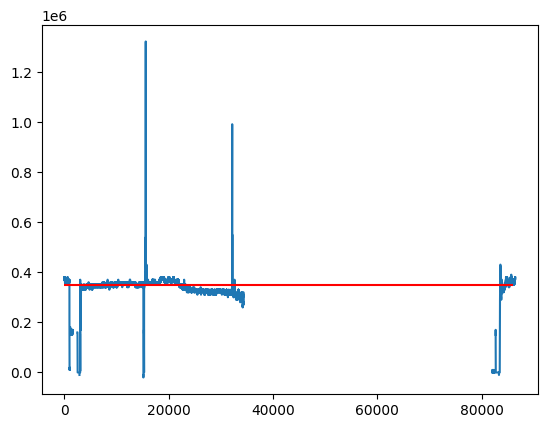

In [170]:
plt.figure()


Jy = df["410"] * 10000 
freq_dfmid = np.nanmedian(Jy)

plt.plot(df["seconds"], Jy)

print(Jy)

plt.hlines(freq_dfmid, xmin=0, xmax=86000, color='red')

In [171]:
chime_data.shape


(1906, 1024)

# Raw data:

The code below first works with fitting a gaussian curve to where the sun is being exposed to in solar flux values.  It is not yet converted into units of Janskys.

[-3.19385041e+06  1.76444051e+03  1.62219263e+02  1.32778545e+07]
errors:[6.52514432e+05 3.04618261e+01 4.95454486e+01 1.85678786e+05]
fit paramenters:[-3.19385041e+06  1.76444051e+03  1.62219263e+02  1.32778545e+07]


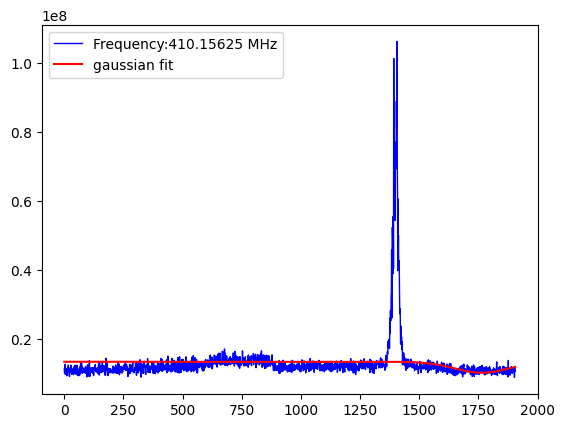

In [172]:
freq_index = 25

y = chime_data[:, freq_index]
x = np.arange(len(y))

#y = the chime data at indicies 
#x= line spacing

#plt.figure()
#plt.plot(x, y)

plt.figure()
def gaus_CHIME(x, a, CHIME_mid, CHIME_sd, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_sd)**2)+d

plt.plot(x, y, color="blue", linewidth=1, label=f"Frequency:{frequency[freq_index]} MHz")
#plt.xlim(1870, 2000)

#parameter guesses:

p0 = (2.4e7, 1925, 50, 1.4e7)

#fitting:

popt, pcov = curve_fit(gaus_CHIME, x, y, p0=p0)
print(popt)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')

#y_fit = def with the initial guesses for data uncalibrated
y_fit = gaus_CHIME(x, popt[0], popt[1], popt[2], popt[3])

plt.plot(x, y_fit, color='red', label='gaussian fit')
plt.legend()
print(f'fit paramenters:{popt}')

a = popt[0]



enter an index to read25
[6.58752191e+07 1.40016307e+03 1.64262682e+01 1.23209313e+07]
errors:[1.21232393e+06 2.43366423e-01 3.58675275e-01 2.86298002e+05]
fit paramenters:[6.58752191e+07 1.40016307e+03 1.64262682e+01 1.23209313e+07]


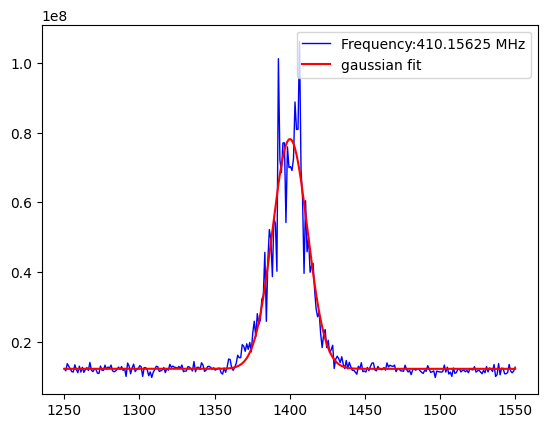

In [177]:
start = 1250
stop = 1550
#user input:

user_input = input("enter an index to read") #input statement for user to use
freq_index = int(user_input)


y = chime_data[start:stop, freq_index]
x = np.linspace(start, stop, num=len(y))

#y = the chime data at indicies 
#x= line spacing

#plt.figure()
#plt.plot(x, y)

plt.figure()
def gaus_CHIME(x, a, CHIME_mid, CHIME_sd, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_sd)**2)+d

plt.plot(x, y, color="blue", linewidth=1, label=f"Frequency:{frequency[freq_index]} MHz")
#plt.xlim(1870, 2000)

#parameter guesses:

p0 = (1.3e8, 1400, 100, 1.4e8)

#fitting:

popt, pcov = curve_fit(gaus_CHIME, x, y, p0=p0)
print(popt)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')

#y_fit = def with the initial guesses for data uncalibrated
y_fit = gaus_CHIME(x, popt[0], popt[1], popt[2], popt[3])

plt.plot(x, y_fit, color='red', label='gaussian fit')
plt.legend()
print(f'fit paramenters:{popt}')

a = popt[0]


In [161]:
chime_data.shape

(2000, 1024)

65875219.05224479
fixed flux:350000.0
[ 2.80000000e+05  3.39320836e+10 -1.32202908e+09  9.93160815e+04]
fit paramenters:[6.58752191e+07 1.40016307e+03 1.64262682e+01 1.23209313e+07]


/users/mburchil/.conda/envs/chime/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


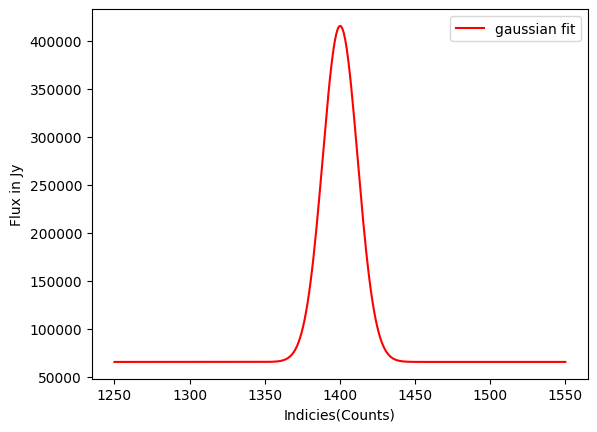

In [178]:
#calibration:

def Jansky_CHIME_Fit(x, a, CHIME_mid_Jy, CHIME_std_Jy, d):
    return a * np.exp(-(x-CHIME_mid_Jy)**2/(CHIME_std_Jy)**2)+d

a = popt[0]
print(a)

mid_flux = np.nanmedian(df["410"] * 10000)
print(f'fixed flux:{mid_flux}')

#Fit_Jy = chime data multiplied by the flux divided by a
converted_y = y_fit * (mid_flux/a)#31 is the average solar flux value for 410 MHz (34 is the median)
#converted_y?
y = chime_data[start:stop, freq_index]

p0 = (280000, 1925, 75, 180000)
popt_raw, pcov = curve_fit(Jansky_CHIME_Fit, x, converted_y, p0=p0)
print(popt_raw)

a = popt_raw[0]

#plotting the fitted Jy

plt.plot(x, converted_y, color='red', label='gaussian fit')
plt.ylabel("Flux in Jy")
plt.xlabel('Indicies(Counts)')
plt.legend()
print(f'fit paramenters:{popt}')


[3.80000000e+05 1.81624430e+03 9.72695146e+01 4.60771559e+06]
errors:[1.33350078e-09 7.01142368e-13 8.08936722e-13 7.19462202e-10]
fit paramenters:[8.51483789e+05 1.81624430e+03 9.72695146e+01 1.03247240e+07]


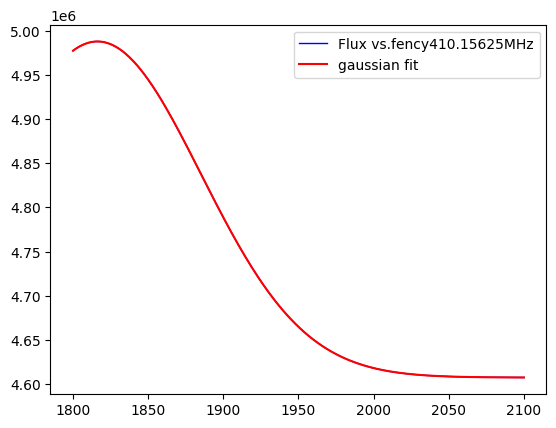

In [163]:
#Raw data(converted to Janskys):



y = chime_data[start:stop, freq_index]
CHIME_mid = np.median(converted_y)
CHIME_std = np.std(converted_y)

converted_raw_y = y * (mid_flux/a)

def Jansky_CHIME_Fit(x, a, CHIME_mid, CHIME_std, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_std)**2)+d


plt.plot(x, converted_y, color='blue', linewidth=1, label=f"Flux vs.fency{frequency[freq_index]}MHz")

#parameter guesses:

p0 = (280000, 1925, 75, 180000)

#fitting:

popt_raw, pcov = curve_fit(Jansky_CHIME_Fit, x, converted_y, p0=p0)
print(popt_raw)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')
y_fit_Jy = Jansky_CHIME_Fit(x, popt_raw[0], popt_raw[1], popt_raw[2], popt_raw[3])

plt.plot(x, y_fit_Jy, color='red', label='gaussian fit')
plt.legend()
print(f'fit paramenters:{popt}')


# Graph of conversions:

values:

the function gaus_CHIME puts in the conversion formula to then be used in the gaussian fit.  p0 puts values into the empty arguements where they are then given values to in popt and popt_Jy.  popt 0 through 3 are amplitude, the median of the data, the standard deviation of the data, and the estimated scaling factor. 

y: The CHIME data to a frequency of 410MHz

x: The line indicies dependent on y to scaling purposes

y_fit: The data for gaussian fit before the Janksy conversion

converted_raw_y: Theaw data(not fitted to a gaussian) converted into units of Janskys

converted_y is the data converted into Janskys but fitted to a gaussian.

I use the function defined above to plot all the graphs depending on their estimation value and the formula for conversion all at 410MHz.

Problems:

Right now, it's fitted to a single solar flux value(this being the median of 410) without accounting for issues regarding solar weather, rotation of the Earth, or where the axis of the Earth is positioned at(Winter vs. Summer).  To address this, there must be a new solar flux value with a daily flux measuremnet instead of a fixed value. 

#Combining the two different plots:

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10,5), sharex='col') #for multiple graphs to exist

user_input = input("enter an index to read") #input statement for user to use
freq_index = int(user_input)


def gaus_CHIME(x, a, CHIME_mid, CHIME_sd, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_sd)**2)+d

ax1.plot(x, y, color="blue", linewidth=1, label=f"Frequency: {frequency[freq_index]} MHz")
#plt.xlim(1870, 2000)
    
#Units are in counts:
p0 = (1.3e8, 1400, 100, 1.4e8)

#fitting:

popt, pcov = curve_fit(gaus_CHIME, x, y, p0=p0)
print(popt)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')

y_fit = gaus_CHIME(x, popt[0], popt[1], popt[2], popt[3])
amp = popt[0]
print(f'amp:{amp}')

ax1.plot(x, y_fit, color='red', label='gaussian fit')
ax1.legend()
ax1.set_ylabel("Flux(counts)")
ax1.set_title("Flux vs. Time in Raw Units")


##############################################################################
#code for converted units to Janskys:

#parameter guesses(for calibrated data):

p0 = (280000, 1400, 50, 180000)

#calculations for converted y values

converted_y = y_fit * (mid_flux/amp)
converted_raw_y = y * (mid_flux/amp)
calibrated_CHIME_dat = chime_data * (mid_flux/amp)

#fitting:

popt_Jy, pcov = curve_fit(Jansky_CHIME_Fit, x, calibrated_CHIME_dat[start:stop, freq_index], p0=p0)
print(popt_Jy)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')
y_fit_Jy = gaus_CHIME(x, popt_Jy[0], popt_Jy[1], popt_Jy[2], popt_Jy[3])

print(f'Frequency peak:{mid_flux}')


ax2.plot(x, converted_raw_y, color='orange', linewidth=1, label=f"Frequency: {frequency[freq_index]}MHz")
ax2.plot(x, y_fit_Jy, color='purple', label='gaussian fit')
ax2.legend()
ax2.set_xlabel("Time(counts)")
ax2.set_ylabel("Flux(Jy)")
ax2.set_title("Flux vs. Time in Units of Janskys")

enter an index to read25
[6.58752191e+07 1.40016307e+03 1.64262682e+01 1.23209313e+07]
errors:[1.21232393e+06 2.43366423e-01 3.58675275e-01 2.86298002e+05]
amp:65875219.05224479
[3.50000516e+05 1.40016309e+03 1.64262107e+01 6.54621048e+04]
errors:[6.44127559e+03 2.43358691e-01 3.58663259e-01 1.52111608e+03]
Frequency peak:350000.0


Text(0.5, 1.0, 'Flux vs. Time in Units of Janskys')

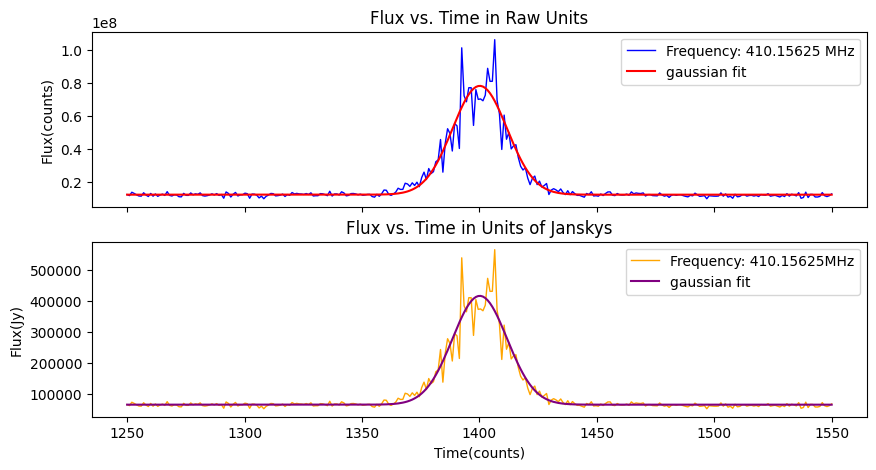

In [183]:
#bining the two different plots:

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10,5), sharex='col') #for multiple graphs to exist

user_input = input("enter an index to read") #input statement for user to use
freq_index = int(user_input)


def gaus_CHIME(x, a, CHIME_mid, CHIME_sd, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_sd)**2)+d

ax1.plot(x, y, color="blue", linewidth=1, label=f"Frequency: {frequency[freq_index]} MHz")
#plt.xlim(1870, 2000)
    
#Units are in counts:
p0 = (1.3e8, 1400, 100, 1.4e8)

#fitting:

popt, pcov = curve_fit(gaus_CHIME, x, y, p0=p0)
print(popt)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')

y_fit = gaus_CHIME(x, popt[0], popt[1], popt[2], popt[3])
amp = popt[0]
print(f'amp:{amp}')

ax1.plot(x, y_fit, color='red', label='gaussian fit')
ax1.legend()
ax1.set_ylabel("Flux(counts)")
ax1.set_title("Flux vs. Time in Raw Units")


##############################################################################
#code for converted units to Janskys:

#parameter guesses(for calibrated data):

p0 = (280000, 1400, 50, 180000)

#calculations for converted y values

converted_y = y_fit * (mid_flux/amp)
converted_raw_y = y * (mid_flux/amp)
calibrated_CHIME_dat = chime_data * (mid_flux/amp)

#fitting:

popt_Jy, pcov = curve_fit(Jansky_CHIME_Fit, x, calibrated_CHIME_dat[start:stop, freq_index], p0=p0)
print(popt_Jy)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')
y_fit_Jy = gaus_CHIME(x, popt_Jy[0], popt_Jy[1], popt_Jy[2], popt_Jy[3])

print(f'Frequency peak:{mid_flux}')


ax2.plot(x, converted_raw_y, color='orange', linewidth=1, label=f"Frequency: {frequency[freq_index]}MHz")
ax2.plot(x, y_fit_Jy, color='purple', label='gaussian fit')
ax2.legend()
ax2.set_xlabel("Time(counts)")
ax2.set_ylabel("Flux(Jy)")
ax2.set_title("Flux vs. Time in Units of Janskys")